In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install numpy
!pip install ultralytics
import cv2
import numpy as np
from ultralytics import YOLO
from IPython.display import Video
import json
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create Video Predictions

In [ ]:
TARGET_CLASSES = {0: "cyclist", 1: "scooter", 2: "person"}

COLORS = {
    "person":   (0, 255, 0),
    "cyclist":  (255, 165, 0),
    "scooter":  (0, 165, 255),
}

VIDEO_SOURCE = '/content/drive/MyDrive/pedestrains_cyclists.mp4'
MODEL = '/content/drive/MyDrive/best.pt'

OVERLAP_THRESHOLD = 0.3
CONFIDENCE = 0.5


def get_frame_difference_mask(frame1, frame2, kernel):
    frame_diff = cv2.absdiff(
        cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY),
        cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    )
    frame_diff = cv2.medianBlur(frame_diff, 3)
    _, mask = cv2.threshold(frame_diff, 25, 255, cv2.THRESH_BINARY)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    motion_boxes = []
    for contour in contours:
        if cv2.contourArea(contour) >= 500:
            x, y, w, h = cv2.boundingRect(contour)
            motion_boxes.append((x, y, x + w, y + h))
    return motion_boxes, mask


def compute_overlap_ratio(detection_box, motion_box):
    x1 = max(detection_box[0], motion_box[0])
    y1 = max(detection_box[1], motion_box[1])
    x2 = min(detection_box[2], motion_box[2])
    y2 = min(detection_box[3], motion_box[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    det_area = (detection_box[2] - detection_box[0]) * (detection_box[3] - detection_box[1])
    if det_area == 0:
        return 0.0
    return intersection / det_area


def fuse_detections(yolo_detections, motion_boxes, overlap_threshold=0.3):
    fused = []
    for det in yolo_detections:
        is_moving = False
        for motion_box in motion_boxes:
            overlap = compute_overlap_ratio(det["bbox"], motion_box)
            if overlap >= overlap_threshold:
                is_moving = True
                break

        fused.append({**det, "moving": is_moving})

    return fused


def draw_results(frame, fused_detections):

    for det in fused_detections:

        x1, y1, x2, y2 = det["bbox"]
        cls = det["class"]
        conf = det["confidence"]
        moving = det["moving"]

        base_color = COLORS.get(cls, (255, 255, 255))
        thickness = 3 if moving else 1

        cv2.rectangle(frame, (x1, y1), (x2, y2), base_color, thickness)
        status = "MOVING" if moving else "stationary"
        label = f"{cls} {conf:.2f} {status}"
        (label_w, label_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(frame,
                      (x1, y1 - label_h - 10),
                      (x1 + label_w, y1),
                      base_color,
                      -1)

        cv2.putText(frame,
                    label,
                    (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 0, 0),
                    2)

    return frame


def main():

    print("Loading YOLO model...")
    model = YOLO(MODEL)
    try:
        model.to('cuda')
    except:
        model.to('cpu')

    video_stream = cv2.VideoCapture(VIDEO_SOURCE)

    if not video_stream.isOpened():
        print("Could not open video")
        return

    ret, prev_frame = video_stream.read()

    if not ret:
        print("Could not read first frame")
        return

    height, width = prev_frame.shape[:2]
    fps = video_stream.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    output_video = "output_overlay.mp4"
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))
    kernel = np.ones((5, 5), np.uint8)
    frame_count = 0

    while True:

        check, current_frame = video_stream.read()

        if not check:
            break

        motion_boxes, motion_mask = get_frame_difference_mask(prev_frame, current_frame, kernel)
        prev_frame = current_frame.copy()
        results = model(current_frame, conf=CONFIDENCE, verbose=False)
        detections = []

        for result in results:
            for box in result.boxes:
                cls_id = int(box.cls[0])
                if cls_id in TARGET_CLASSES:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                    detections.append({
                        "bbox": (x1, y1, x2, y2),
                        "class": TARGET_CLASSES[cls_id],
                        "confidence": float(box.conf[0])
                    })

        fused = fuse_detections(detections, motion_boxes, OVERLAP_THRESHOLD)
        out_frame = draw_results(current_frame.copy(), fused)
        out.write(out_frame)
        frame_count += 1

        if frame_count % 50 == 0:
            print("Processed frame:", frame_count)

    video_stream.release()
    out.release()
    print("Video saved:", output_video)
    return output_video


video_path = main()
Video(video_path)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading YOLO model...
Processed frame: 50
Processed frame: 100


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO
import yaml
import os

VAL_IMAGES_DIR = "dataset/images/val"
CLASS_NAMES = ['person', 'cyclist', 'scooter']

data_yaml = {
    'names': CLASS_NAMES,
    'nc': len(CLASS_NAMES),
    'val': VAL_IMAGES_DIR
}

yaml_path = "data_val.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(data_yaml)

model = YOLO("best.pt")

metrics = model.val(data=yaml_path)
print(metrics)

# Performance Metrics

### Helper Functions

In [ ]:
# MOTION DETECTION
def get_frame_difference_mask(frame1, frame2, kernel):

    frame_diff = cv2.absdiff(
        cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY),
        cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    )

    frame_diff = cv2.medianBlur(frame_diff, 3)

    _, mask = cv2.threshold(frame_diff, 25, 255, cv2.THRESH_BINARY)

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    motion_boxes = []
    for contour in contours:
        if cv2.contourArea(contour) >= 500:
            x, y, w, h = cv2.boundingRect(contour)
            motion_boxes.append((x, y, x + w, y + h))

    return motion_boxes, mask


def compute_overlap_ratio(detection_box, motion_box):
    x1 = max(detection_box[0], motion_box[0])
    y1 = max(detection_box[1], motion_box[1])
    x2 = min(detection_box[2], motion_box[2])
    y2 = min(detection_box[3], motion_box[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    det_area = (detection_box[2] - detection_box[0]) * (detection_box[3] - detection_box[1])

    if det_area == 0:
        return 0.0

    return intersection / det_area

def is_moving(det_box, motion_boxes):
    for mbox in motion_boxes:
        if compute_overlap_ratio(det_box, mbox) >= OVERLAP_THRESHOLD:
            return True
    return False



# IoU MATCHING

def compute_iou(boxA, boxB):
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - intersection
    return intersection / union if union > 0 else 0.0


def match_predictions_to_gt(predictions, gt_list):
    pairs = []
    matched_gt = set()

    for pred in predictions:
        best_iou    = 0
        best_gt_idx = -1
        for i, gt in enumerate(gt_list):
            if i in matched_gt:
                continue
            iou = compute_iou(pred["bbox_xyxy"], gt["bbox_xyxy"])
            if iou > best_iou:
                best_iou    = iou
                best_gt_idx = i

        if best_iou >= IOU_THRESHOLD and best_gt_idx >= 0:
            matched_gt.add(best_gt_idx)
            pairs.append((gt_list[best_gt_idx]["label"], pred["label"]))
        else:
            pairs.append(("background", pred["label"]))  # false positive

    # Unmatched GT = false negatives
    for i, gt in enumerate(gt_list):
        if i not in matched_gt:
            pairs.append((gt["label"], "background"))

    return pairs



# LOAD CVAT GROUND TRUTH
def load_ground_truth(json_path):
    with open(json_path) as f:
        coco = json.load(f)

    cat_map = {cat["id"]: cat["name"] for cat in coco["categories"]}
    img_map = {img["id"]: img["file_name"] for img in coco["images"]}

    gt_by_file = defaultdict(list)
    for ann in coco["annotations"]:
        file_name = img_map[ann["image_id"]]
        x, y, w, h = ann["bbox"]
        gt_by_file[file_name].append({
            "bbox_xyxy": (int(x), int(y), int(x + w), int(y + h)),
            "label":     cat_map[ann["category_id"]]
        })

    print(f"  Loaded GT: {len(coco['images'])} images, {len(coco['annotations'])} annotations")
    return gt_by_file

def plot_confusion_matrix(y_true, y_pred):
    present = sorted(set(y_true + y_pred))
    cm      = confusion_matrix(y_true, y_pred, labels=present)
    disp    = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present)

    fig, ax = plt.subplots(figsize=(12, 10))
    disp.plot(ax=ax, cmap="Oranges", colorbar=True)
    plt.xticks(rotation=45, ha="right")
    plt.title("Confusion Matrix — Moving vs Stationary Detection (All Videos)", fontsize=14)
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("Saved → confusion_matrix.png")

    print(f"\n  {'Label':<25} {'TP':>5} {'Total GT':>10} {'Recall':>8}")
    print("  " + "-" * 52)
    for label in present:
        if label == "background":
            continue
        idx    = present.index(label)
        tp     = cm[idx][idx]
        total  = cm[idx].sum()
        recall = tp / total if total > 0 else 0.0
        print(f"  {label:<25} {tp:>5} {total:>10} {recall:>8.1%}")

    try:
        from google.colab import files
        files.download("confusion_matrix.png")
    except ImportError:
        pass

# process one video
def process_video(video_path, gt_by_file, model):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"  Could not open {video_path}")
        return [], []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ret, prev_frame = cap.read()
    if not ret:
        cap.release()
        return [], []

    kernel   = np.ones((5, 5), np.uint8)
    all_true = []
    all_pred = []
    frame_id = 0

    while True:
        ret, current_frame = cap.read()
        if not ret:
            break

        if frame_id % FRAME_SAMPLE_RATE == 0:
            file_name    = f"frame_{frame_id:05d}.jpg"
            gt_list      = gt_by_file.get(file_name, [])
            motion_boxes, _ = get_frame_difference_mask(prev_frame, current_frame, kernel)
            results      = model(current_frame, conf=CONFIDENCE, verbose=False)
            predictions  = []

            for result in results:
                for box in result.boxes:
                    cls_id = int(box.cls[0])
                    if cls_id not in TARGET_CLASSES:
                        continue
                    x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
                    cls_name = TARGET_CLASSES[cls_id]
                    moving   = is_moving((x1, y1, x2, y2), motion_boxes)
                    label    = f"{cls_name}_{'moving' if moving else 'stationary'}"
                    predictions.append({
                        "bbox_xyxy": (x1, y1, x2, y2),
                        "label":     label
                    })

            pairs = match_predictions_to_gt(predictions, gt_list)
            for gt_label, pred_label in pairs:
                all_true.append(gt_label)
                all_pred.append(pred_label)

            if frame_id % 100 == 0:
                print(f"    Frame {frame_id}/{total_frames} — {len(all_true)} pairs so far")

        prev_frame = current_frame.copy()
        frame_id  += 1

    cap.release()
    return all_true, all_pred




### Pre-annotions to COCO 1.0
Get predicted annotations as a COCO 1.0 file to export to CVAT as preliminary annotations to edit and create ground truth

In [ ]:
import cv2
import json
import numpy as np
from ultralytics import YOLO

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────

VIDEO_SOURCE       = '/content/drive/MyDrive/pedestrians_cyclists.mp4'
MODEL_PATH         = '/content/drive/MyDrive/best.pt'
COCO_OUT_FILE      = 'coco_annotations.json'
CONFIDENCE         = 0.5
FRAME_SAMPLE_RATE  = 5
OVERLAP_THRESHOLD  = 0.3

TARGET_CLASSES = {0: "cyclist", 1: "scooter", 2: "person"}

CLASSES = [
    "person_moving",
    "person_stationary",
    "cyclist_moving",
    "cyclist_stationary",
    "scooter_moving",
    "scooter_stationary",
]

# CVAT requires category IDs starting at 1
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES, start=1)}



# MAIN

def main():
    print("Loading YOLO model...")
    model = YOLO(MODEL_PATH)
    try:
        model.to('cuda')
        print("  Using GPU")
    except:
        model.to('cpu')
        print("  Using CPU")

    cap = cv2.VideoCapture(VIDEO_SOURCE)
    if not cap.isOpened():
        print("Could not open video")
        return

    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"  Video: {width}x{height}, ~{total_frames} frames")
    print(f"  Sampling every {FRAME_SAMPLE_RATE} frames → ~{total_frames // FRAME_SAMPLE_RATE} images\n")

    ret, prev_frame = cap.read()
    if not ret:
        print("Could not read first frame")
        return

    kernel        = np.ones((5, 5), np.uint8)
    coco_images   = []
    coco_annotations = []
    image_id      = 1   # increments for EVERY sampled frame, with or without detections
    annotation_id = 1
    frame_id      = 0

    while True:
        ret, current_frame = cap.read()
        if not ret:
            break

        if frame_id % FRAME_SAMPLE_RATE == 0:

            # Always register this frame — keeps image_id in sync with CVAT uploads
            coco_images.append({
                "id":        int(image_id),
                "file_name": f"frame_{frame_id:05d}.jpg",  # matches extract_frames.py naming
                "width":     int(width),
                "height":    int(height),
            })

            motion_boxes, mask = get_frame_difference_mask(prev_frame, current_frame, kernel)
            results      = model(current_frame, conf=CONFIDENCE, verbose=False)

            for result in results:
                for box in result.boxes:
                    cls_id = int(box.cls[0])
                    if cls_id not in TARGET_CLASSES:
                        continue

                    x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
                    detection_box  = (x1, y1, x2, y2)
                    cls_name = TARGET_CLASSES[cls_id]
                    moving   = is_moving(detection_box, motion_boxes)
                    label    = f"{cls_name}_{'moving' if moving else 'stationary'}"

                    bw = int(x2 - x1)
                    bh = int(y2 - y1)

                    coco_annotations.append({
                        "id":           int(annotation_id),
                        "image_id":     int(image_id),          # tied to frame registered above
                        "category_id":  int(CLASS_TO_ID[label]),
                        "bbox":         [x1, y1, bw, bh],       # COCO: [x, y, w, h]
                        "area":         int(bw * bh),
                        "iscrowd":      0,
                        "segmentation": [],
                    })
                    annotation_id += 1

            image_id += 1   # always increment, even for frames with no detections

            if frame_id % 100 == 0:
                print(f"  Processed frame {frame_id}/{total_frames} — {len(coco_annotations)} annotations so far")

        prev_frame = current_frame.copy()
        frame_id += 1

    cap.release()

    # ── Build COCO JSON ──
    coco = {
        "info": {
            "description": "Auto-generated ground truth — moving/stationary detection",
            "version":     "1.0",
            "year":        2025,
            "contributor": "",
            "date_created": ""
        },
        "licenses": [],
        "categories": [
            {
                "id":            i,
                "name":          cls,
                "supercategory": cls.split("_")[0]
            }
            for i, cls in enumerate(CLASSES, start=1)
        ],
        "images":      coco_images,
        "annotations": coco_annotations,
    }

    with open(COCO_OUT_FILE, "w") as f:
        json.dump(coco, f, indent=2)

    # ── Summary ──
    print(f"\n COCO file saved → {COCO_OUT_FILE}")
    print(f"   Images registered : {len(coco_images)}")
    print(f"   Annotations       : {len(coco_annotations)}")

    from collections import Counter
    class_counts = Counter(
        next(cls for cls, cid in CLASS_TO_ID.items() if cid == a["category_id"])
        for a in coco_annotations
    )
    print("\n   Class breakdown:")
    for cls, count in sorted(class_counts.items()):
        print(f"     {cls:<25} {count}")

    print("\n  CVAT import checklist:")
    print(f"   1. CVAT task must have these exact label names:")
    for cls in CLASSES:
        print(f"      - {cls}")
    print(f"   2. Frames uploaded to CVAT must use FRAME_SAMPLE_RATE = {FRAME_SAMPLE_RATE}")
    print(f"   3. Import via: Actions → Upload annotations → COCO 1.0")

    try:
        from google.colab import files
        files.download(COCO_OUT_FILE)
        print("\n   Download started!")
    except ImportError:
        import os
        print(f"\n   Not in Colab — file at: {os.path.abspath(COCO_OUT_FILE)}")


main()

Loading YOLO model...
  Using CPU
Could not open video


### Export images, every 5th frame for creating Ground Truth

In [ ]:
import cv2
import os
import zipfile

VIDEO_SOURCE = '/content/drive/MyDrive/ee146-project/Videos/pedestrians_cyclists.mp4'
OUTPUT_DIR = "gt_frames"
FRAME_SAMPLE_RATE = 5
ZIP_OUTPUT = "gt_frames.zip"

os.makedirs(OUTPUT_DIR, exist_ok=True)

cap = cv2.VideoCapture(VIDEO_SOURCE)
frame_id = 0
saved = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_id % FRAME_SAMPLE_RATE == 0:
        path = f"{OUTPUT_DIR}/frame_{frame_id:05d}.jpg"
        cv2.imwrite(path, frame)
        saved.append(path)
    frame_id += 1

cap.release()
print(f"Saved {len(saved)} frames to {OUTPUT_DIR}/")

# Zip all frames
with zipfile.ZipFile(ZIP_OUTPUT, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in saved:
        zf.write(path, arcname=os.path.basename(path))

print(f"Zipped to {ZIP_OUTPUT}")

# Download in Google Colab
try:
    from google.colab import files
    files.download(ZIP_OUTPUT)
    print("Download started!")
except ImportError:
    print(f"Not in Colab — find your zip at: {os.path.abspath(ZIP_OUTPUT)}")

Saved 0 frames to gt_frames/
Zipped to gt_frames.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


## YOLO Model + Motion Confusion Matrix


Loading YOLO model...
  Using CPU

── Video 1: /content/drive/MyDrive/escooter.mp4
  Loading ground truth...
  Loaded GT: 93 images, 488 annotations
  Running predictions...
    Frame 0/463 — 6 pairs so far
    Frame 100/463 — 177 pairs so far
    Frame 200/463 — 363 pairs so far
    Frame 300/463 — 455 pairs so far
    Frame 400/463 — 493 pairs so far
  Video 1 pairs: 519

── Video 2: /content/drive/MyDrive/pedestrians_cyclists.mp4
  Loading ground truth...
  Loaded GT: 66 images, 363 annotations
  Running predictions...
    Frame 0/327 — 5 pairs so far
    Frame 100/327 — 103 pairs so far
    Frame 200/327 — 218 pairs so far
    Frame 300/327 — 343 pairs so far
  Video 2 pairs: 372

── Combined results across 2 videos
  Total pairs : 891
  Correct     : 583
  False pos   : 40
  False neg   : 96

Evaluation Metrics
------------------
True Positives : 583
False Positives: 40
False Negatives: 96
Precision      : 0.9358
Recall         : 0.8586
F1 Score       : 0.8955

Plotting combined c

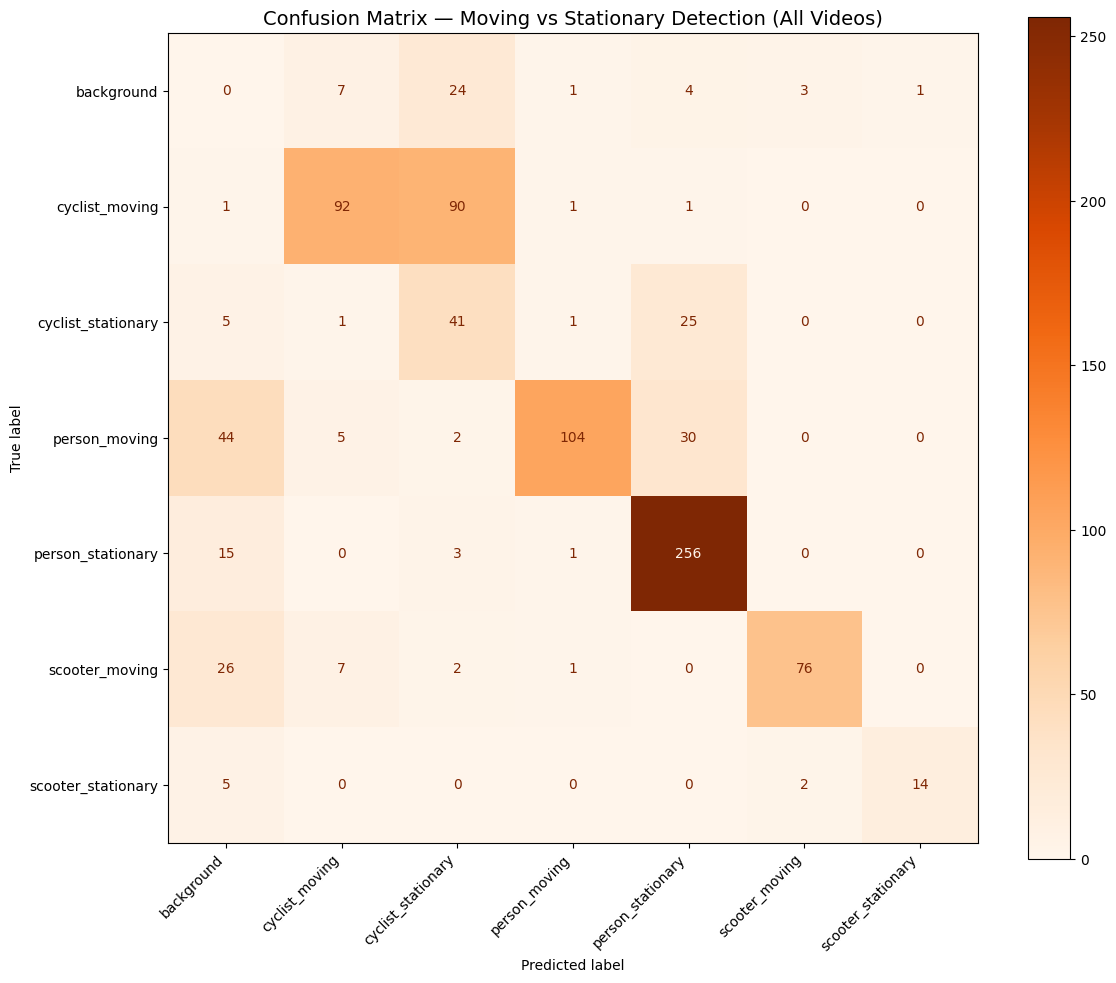

Saved → confusion_matrix.png

  Label                        TP   Total GT   Recall
  ----------------------------------------------------
  cyclist_moving               92        185    49.7%
  cyclist_stationary           41         73    56.2%
  person_moving               104        185    56.2%
  person_stationary           256        275    93.1%
  scooter_moving               76        112    67.9%
  scooter_stationary           14         21    66.7%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

MODEL_PATH        = '/content/drive/MyDrive/best.pt'
VIDEOS = [
    {
        "video":        '/content/drive/MyDrive/escooter.mp4',
        "ground_truth": '/content/drive/MyDrive/instances_default.json',
    },
    {
        "video":        '/content/drive/MyDrive/pedestrians_cyclists.mp4',
        "ground_truth": '/content/drive/MyDrive/instances_cyclist.json',
    },
]

CONFIDENCE        = 0.5
FRAME_SAMPLE_RATE = 5
OVERLAP_THRESHOLD = 0.3
IOU_THRESHOLD     = 0.5

TARGET_CLASSES = {0: "cyclist", 1: "scooter", 2: "person"}

CLASSES = [
    "person_moving",
    "person_stationary",
    "cyclist_moving",
    "cyclist_stationary",
    "scooter_moving",
    "scooter_stationary",
]


def main():
    print("Loading YOLO model...")
    model = YOLO(MODEL_PATH)
    try:
        model.to('cuda')
        print("  Using GPU")
    except:
        model.to('cpu')
        print("  Using CPU")

    all_true_combined = []
    all_pred_combined = []

    for i, entry in enumerate(VIDEOS):
        print(f"\n── Video {i + 1}: {entry['video']}")
        print(f"  Loading ground truth...")
        gt_by_file = load_ground_truth(entry["ground_truth"])

        print(f"  Running predictions...")
        true_labels, pred_labels = process_video(entry["video"], gt_by_file, model)

        print(f"  Video {i + 1} pairs: {len(true_labels)}")

        # Merge results from this video into combined lists ✅
        all_true_combined.extend(true_labels)
        all_pred_combined.extend(pred_labels)

    print(f"\n── Combined results across {len(VIDEOS)} videos")
    print(f"  Total pairs : {len(all_true_combined)}")
    print(f"  Correct     : {sum(t == p for t, p in zip(all_true_combined, all_pred_combined))}")
    print(f"  False pos   : {sum(t == 'background' for t in all_true_combined)}")
    print(f"  False neg   : {sum(p == 'background' for p in all_pred_combined)}")

    # Calculate metrics
    TP = sum((t == p) and (t != "background") for t, p in zip(all_true_combined, all_pred_combined))
    FP = sum((t == "background") and (p != "background") for t, p in zip(all_true_combined, all_pred_combined))
    FN = sum((t != "background") and (p == "background") for t, p in zip(all_true_combined, all_pred_combined))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print("\nEvaluation Metrics")
    print("------------------")
    print(f"True Positives : {TP}")
    print(f"False Positives: {FP}")
    print(f"False Negatives: {FN}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")

    print("\nPlotting combined confusion matrix...")
    plot_confusion_matrix(all_true_combined, all_pred_combined)


main()

## YOLO Model Confusion Matrix

In [ ]:
import pandas as pd
from ultralytics import YOLO

MODEL_PATH  = "best.pt"
DATA_YAML   = "data.yaml"
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

CLASS_NAMES = {0: "cyclist", 1: "e-scooter", 2: "person"}

model = YOLO(MODEL_PATH)

val_results = model.val(
    data=DATA_YAML,
    split="val",
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    plots=True,
)

p  = val_results.box.mp
r  = val_results.box.mr
f1 = 2 * (p * r) / (p + r + 1e-9)

print("OVERALL METRICS")
print(f"   mAP@0.5      : {val_results.box.map50:.4f}")
print(f"   mAP@0.5:0.95 : {val_results.box.map:.4f}")
print(f"   Precision    : {p:.4f}")
print(f"   Recall       : {r:.4f}")
print(f"   F1 Score     : {f1:.4f}")

per_class_p  = val_results.box.p[:3]
per_class_r  = val_results.box.r[:3]
per_class_f1 = 2 * (per_class_p * per_class_r) / (per_class_p + per_class_r + 1e-9)

df = pd.DataFrame({
    "Class"        : list(CLASS_NAMES.values()),
    "Precision"    : per_class_p,
    "Recall"       : per_class_r,
    "F1"           : per_class_f1,
    "mAP@0.5"      : val_results.box.ap50[:3],
    "mAP@0.5:0.95" : val_results.box.ap[:3],
})
print("PER-CLASS")
print(df.to_string(index=False))

# Training the Dataset

In [ ]:
!pip install roboflow ultralytics
from ultralytics import YOLO
import os
from roboflow import Roboflow
import yaml
import os

rf = Roboflow(api_key="INSERT_KEY_HERE")
project = rf.workspace("gages-workspace").project("smart-city-pedestrian-bike-detection-dy7rr")
version = project.version(1)
dataset = version.download("yolov8")

with open(os.path.join("Smart-city-pedestrian/bike-detection-1", "data.yaml"), "r") as f:
    data = yaml.safe_load(f)

print(data["names"])

model = YOLO("yolov8s.pt")
dataset_path = "Smart-city-pedestrian/bike-detection-1"

model.train(
    data=os.path.join(dataset_path, "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    name="people_cyclists_scooters")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 


Extracting Dataset Version Zip to Smart-city-pedestrian/bike-detection-1 in yolov8:: 100%|██████████| 9694/9694 [00:09<00:00, 984.29it/s] 


['cyclist', 'e-scooter', 'person', 'vehicles']
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Smart-city-pedestrian/bike-detection-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=people_cyclists_scooters, nbs=64, nms=False, ops

KeyboardInterrupt: 